# **Circular Data** 

### Import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from scipy.stats import gaussian_kde, vonmises
import traceback

import pycircstat2.hypothesis as circ


### Data Preparation for Processing

**Load data:**

In [3]:
data = pd.read_csv(r"C:\Users\modri\Downloads\Track stats 2026-04-23 (2).csv")
data

,Condition,Replicate,Track ID,Track UID,Track length,Speed min,Speed max,Speed mean,Speed sd,Speed median,...,Track end time,Mean straight line speed,Forward progression linearity,Direction mean,Direction var,Mean directional change,Mean directional change rate,Track displacement,Straightness ratio,Track points
0,CXCL12,1,0.0,0,2.214566,0.008202,0.008202,0.008202,0.000000,0.008202,...,270.0,0.002051,0.250000,3.141593,0.666667,180.000000,0.500000,0.738189,0.333333,4
1,CXCL12,1,1.0,1,209.331875,0.000000,0.157770,0.027689,0.028237,0.021473,...,8010.0,0.003591,0.137413,0.199245,0.846291,80.851038,0.010569,27.472120,0.131237,85
2,CXCL12,1,2.0,2,101.320654,0.000000,0.046398,0.012649,0.008844,0.011600,...,8010.0,0.000465,0.036737,0.707193,0.895794,93.417613,0.011533,3.764038,0.037150,90
3,CXCL12,1,3.0,3,19.166862,0.018340,0.049213,0.035494,0.010781,0.037414,...,720.0,0.004831,0.181482,2.911379,0.929011,91.090524,0.144588,3.043629,0.158796,7
4,CXCL12,1,4.0,4,87.900107,0.008202,0.049891,0.024417,0.013363,0.023199,...,3690.0,0.003453,0.144973,3.027318,0.889423,108.166041,0.029313,12.743110,0.144973,41
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6781,CXCL12,3,2_95.0,9480,289.310601,0.000000,0.077812,0.036119,0.020056,0.033818,...,8010.0,0.000547,0.015139,-2.602266,0.956229,103.853199,0.012821,4.429131,0.015309,90
6782,CXCL12,3,2_96.0,9481,274.365412,0.000000,0.106942,0.034253,0.022340,0.025937,...,8010.0,0.000735,0.021451,-0.628352,0.954318,71.011144,0.008767,5.951466,0.021692,90
6783,CXCL12,3,2_97.0,9482,23.117825,0.000000,0.070079,0.023351,0.020064,0.018340,...,990.0,0.012322,0.527683,0.940916,0.568843,83.167206,0.077007,13.307883,0.575655,12
6784,CXCL12,3,2_98.0,9483,208.670073,0.000000,0.075620,0.026051,0.016754,0.018340,...,8010.0,0.000951,0.036523,1.084389,0.935816,94.549615,0.011673,7.706914,0.036933,90


**Dummie (simulated) data:**

In [4]:
test_data_random = np.linspace(0, 2 * np.pi, 2500, endpoint=False)              # random data
test_data_single = np.linspace(0, 0, 2500, endpoint=False)                      # single value data
test_data_biased = np.random.vonmises(mu=np.deg2rad(0), kappa=10, size=2500)   # biased data

**Automation helper dicionary:**

In [5]:
all_angles = data["Direction mean"].values
rep_angles = {n: data.loc[data["Replicate"] == n, "Direction mean"].values for n in range(1, 4)}

group_angles = {
    "All": all_angles,
    **{f"{n}": angles for n, angles in rep_angles.items()},
    "Random": test_data_random,
    "Single": test_data_single,
    "Bias": test_data_biased
}


## Plotting functions

**Save to SVG function:**

In [6]:
def save_svg(fig: plt.Figure, filename: str):
    fig.savefig(filename, format='svg', bbox_inches='tight')

**Classical ploar distribution plot:**

In [22]:
def classic_polar_dist(data: pd.Series, *, bins: int = 72, kappa: float = 25, ratio: float = 0.4, title_suffix: str = '', fig=None, ax=None) -> plt.Figure:
    
    # Wrap angles
    a = np.asarray(data, dtype=float)
    a = a % (2 * np.pi)

    check = np.isfinite(a)
    angles = a[check]

    # Create polar plot
    if fig is None or ax is None:
        fig, ax = plt.subplots(subplot_kw={"projection": "polar"})
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_axis_off()

    # Rose histogram
    edges = np.linspace(0, 2 * np.pi, bins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    widths = np.diff(edges)

    if angles.size > 0:
        counts, _ = np.histogram(angles, bins=edges)
        counts = counts.astype(float)
        if counts.max() > 0:
            counts /= counts.max()
    else:
        counts = np.zeros(bins, dtype=float)

    base_radius = 1
    hist_band = ratio
    bar_heights = counts * hist_band

    theta_circle = np.linspace(0, 2 * np.pi, 720, endpoint=False)
    ax.plot(theta_circle, np.full_like(theta_circle, base_radius-0.02),
            color="#C9CCCD", lw=1.25, zorder=2)

    ax.bar(
        centers,
        bar_heights,
        width=widths,
        bottom=base_radius,
        align="center",
        color="#72b2df",
        edgecolor="white",
        linewidth=0.7,
        alpha=0.95,
        zorder=3
    )

    # Density estimation using von Mises distribution
    n = 1440
    if angles.size < 2:
        theta = np.linspace(-np.pi, np.pi, n, endpoint=False)
        density = np.zeros(n, dtype=float)
    else:
        theta = np.linspace(0, 2 * np.pi, n, endpoint=False)
        density = np.mean(
            vonmises.pdf(theta[:, None], kappa, loc=angles),
            axis=1
        )
        density = density - (density.max()/2)

    density_offset = base_radius + hist_band + 0.05
    density_r = density + density_offset

    ax.plot(theta, density_r, color="#5f91d3", lw=1, zorder=5)

    # Adjust y-limits, axes and grid
    ax.set_ylim(0, float(np.nanmax(density_r) + 0.05) if density_r.size else 1.6)
    ax.set_yticklabels([])
    ax.grid(False)

    # Title and annotations (annotations positioned relative to title pad, not data/axes coords)
    title = ax.set_title(
        f"Circular distribution {title_suffix}",
        va='bottom',
        fontsize=10,
        fontweight='bold',
        pad=40
    )

    tx, ty = title.get_position()
    tform = title.get_transform()

    ax.text(
        tx, ty, f"kappa: {kappa}",
        transform=mpl.transforms.offset_copy(tform, fig=fig, x=0, y=-5, units='points'),
        ha='center', va='top', fontsize=9, fontweight='medium'
    )
    ax.text(
        tx, ty, f"n: {angles.size}",
        transform=mpl.transforms.offset_copy(tform, fig=fig, x=0, y=-18, units='points'),
        ha='center', va='top', fontsize=9, fontweight='medium'
    )

    ax.text(0, 0.8, "0°", ha='center', va='bottom', fontsize=8, fontweight='light')
    ax.text(np.pi/2, 0.915, "90°", ha='right', va='center', fontsize=8, fontweight='light')
    ax.text(np.pi, 0.8, "180°", ha='center', va='top', fontsize=8, fontweight='light')
    ax.text(3*np.pi/2, 0.915, "270°", ha='left', va='center', fontsize=8, fontweight='light')

    return plt.gcf()


**Polar plot showing replicate circular means:**

In [8]:
def polar_rep_bullets(
    data: pd.DataFrame,
    *,
    marker_size: float = 5.0,
    title_suffix: str = "",
    rep_col: str = "Replicate",
    bullet_sep_deg: float = 4.0,   # min angular separation on a single ring
    bullet_step: float = 0.05,     # spacing between rings
    max_rings: int = 12,
    colors: list = None
) -> plt.Figure:
    
    reps = data[rep_col].unique()
    
    # Assign colors
    def _rand_color():
        return f'#{np.random.randint(0, 0xFFFFFF):06x}'
    
    if colors is None:
        colors = {rep: _rand_color() for rep in reps}
    else:
        try:
            colors = {rep: colors[i % len(colors)] for i, rep in enumerate(reps)}   
        except Exception as e:
            print("Error processing colors:", e)
            traceback.print_exc()
            colors = {rep: _rand_color() for rep in reps}

    # Create polar plot
    fig, ax = plt.subplots(subplot_kw={"projection": "polar"})
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_axis_off()

    # Compute circular means for each replicate
    rep_cir_means = {}
    for rep in reps:
        rep_angles = data.loc[data[rep_col] == rep, "Direction mean"].values
        rep_angles = np.asarray(rep_angles, dtype=float) % (2 * np.pi)
        rep_angles = rep_angles[np.isfinite(rep_angles)]
        if rep_angles.size > 0:
            rep_cir_means[rep] = np.arctan2(np.mean(np.sin(rep_angles)), np.mean(np.cos(rep_angles))) % (2 * np.pi)
        else:
            rep_cir_means[rep] = np.nan

    # Draw base circle
    base_radius = 0.975
    theta_circle = np.linspace(0, 2 * np.pi, 720, endpoint=False)
    ax.plot(theta_circle, np.full_like(theta_circle, base_radius - 0.02),
            color="#C9CCCD", lw=1.25, zorder=2)

    # Calculate bullet positions with collision avoidance
    min_sep = np.deg2rad(bullet_sep_deg)
    ring_thetas = [[] for _ in range(max_rings)]
    items = [(rep, th) for rep, th in rep_cir_means.items() if np.isfinite(th)]
    items.sort(key=lambda x: x[1])

    # Place bullets with collision avoidance
    def circ_diff(a: float, b: float) -> float:
        d = abs(a - b)
        return min(d, 2 * np.pi - d)
    
    max_used_ring = 0
    for rep, th in items:
        rep_n = data.loc[data[rep_col] == rep, "Direction mean"].size

        ring = None
        for i in range(max_rings):
            if all(circ_diff(th, t_old) >= min_sep for t_old in ring_thetas[i]):
                ring = i
                break
        if ring is None:
            ring = max_rings - 1  # fallback in case of high data density

        ring_thetas[ring].append(th)
        max_used_ring = max(max_used_ring, ring)
        r = base_radius + ring * marker_size / 90 + 0.035

        ax.plot(
            th, r, "o",
            color=colors[rep],
            markersize=marker_size,
            markeredgecolor="#F9F9F9",
            markeredgewidth=0.2,
            zorder=4
        )

    # Adjust y-limits, axes and grid
    ylim_top = max(1.6, base_radius + (max_used_ring + 1) * bullet_step + 0.5)
    ax.set_ylim(0, ylim_top)
    ax.set_yticklabels([])
    ax.grid(False)

    # Add total average arrow
    total_avg = np.arctan2(np.mean(np.sin(list(rep_cir_means.values()))), np.mean(np.cos(list(rep_cir_means.values())))) % (2 * np.pi)
    ax.annotate("", arrowprops=dict(arrowstyle="->", color="#5B6B7B", lw=1.25), xy=(total_avg, base_radius + 0.125), xytext=(total_avg, base_radius - 0.115))

    # Title and annotations
    ax.set_title(f"Circular distribution {title_suffix}", va="bottom", fontsize=10, fontweight="bold", pad=30)

    add = 0.3
    for _rep in reps:
        rep_n = data.loc[data[rep_col] == _rep, "Direction mean"].size
        at_angle = rep_cir_means[_rep]
        ax.text(0, ylim_top + add + 0.025, f"●                     ", ha="center", va="top", fontsize=9, fontweight="bold", color=colors[_rep])
        ax.text(0, ylim_top + add, f"      {np.rad2deg(at_angle):.1f}°  (n: {rep_n})", ha="center", va="top", fontsize=8, fontweight="medium")
        add -= 0.145

    ax.annotate('', xy=(-0.24, ylim_top - 0.04), xytext=(-0.3, ylim_top + add - 0.04), textcoords='data', arrowprops=dict(arrowstyle="->", color="#5B6B7B", lw=1.25), zorder=6)
    ax.text(0, ylim_top + (0.3 - 0.145*3), f"             Total average: {np.rad2deg(total_avg):.1f}°", ha="center", va="top", fontsize=8, fontweight="medium")

    ax.text(0, 0.8, "0°", ha="center", va="bottom", fontsize=8, fontweight="light")
    ax.text(np.pi / 2, 0.915, "90°", ha="right", va="center", fontsize=8, fontweight="light")
    ax.text(np.pi, 0.8, "180°", ha="center", va="top", fontsize=8, fontweight="light")
    ax.text(3 * np.pi / 2, 0.915, "270°", ha="left", va="center", fontsize=8, fontweight="light")

    return plt.gcf()


## Plot generation and SVG export 

**Bullet polar plot:**

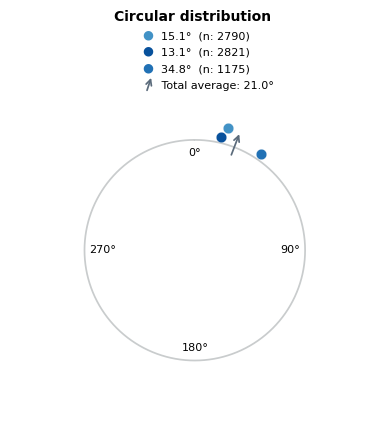

In [9]:
plot = polar_rep_bullets(data, marker_size=7.5, colors = ["#4292c6", "#08519c", "#2171b5"])
save_svg(plot, "replicate_bullets.svg")

**Classical distribution for all data groups:**

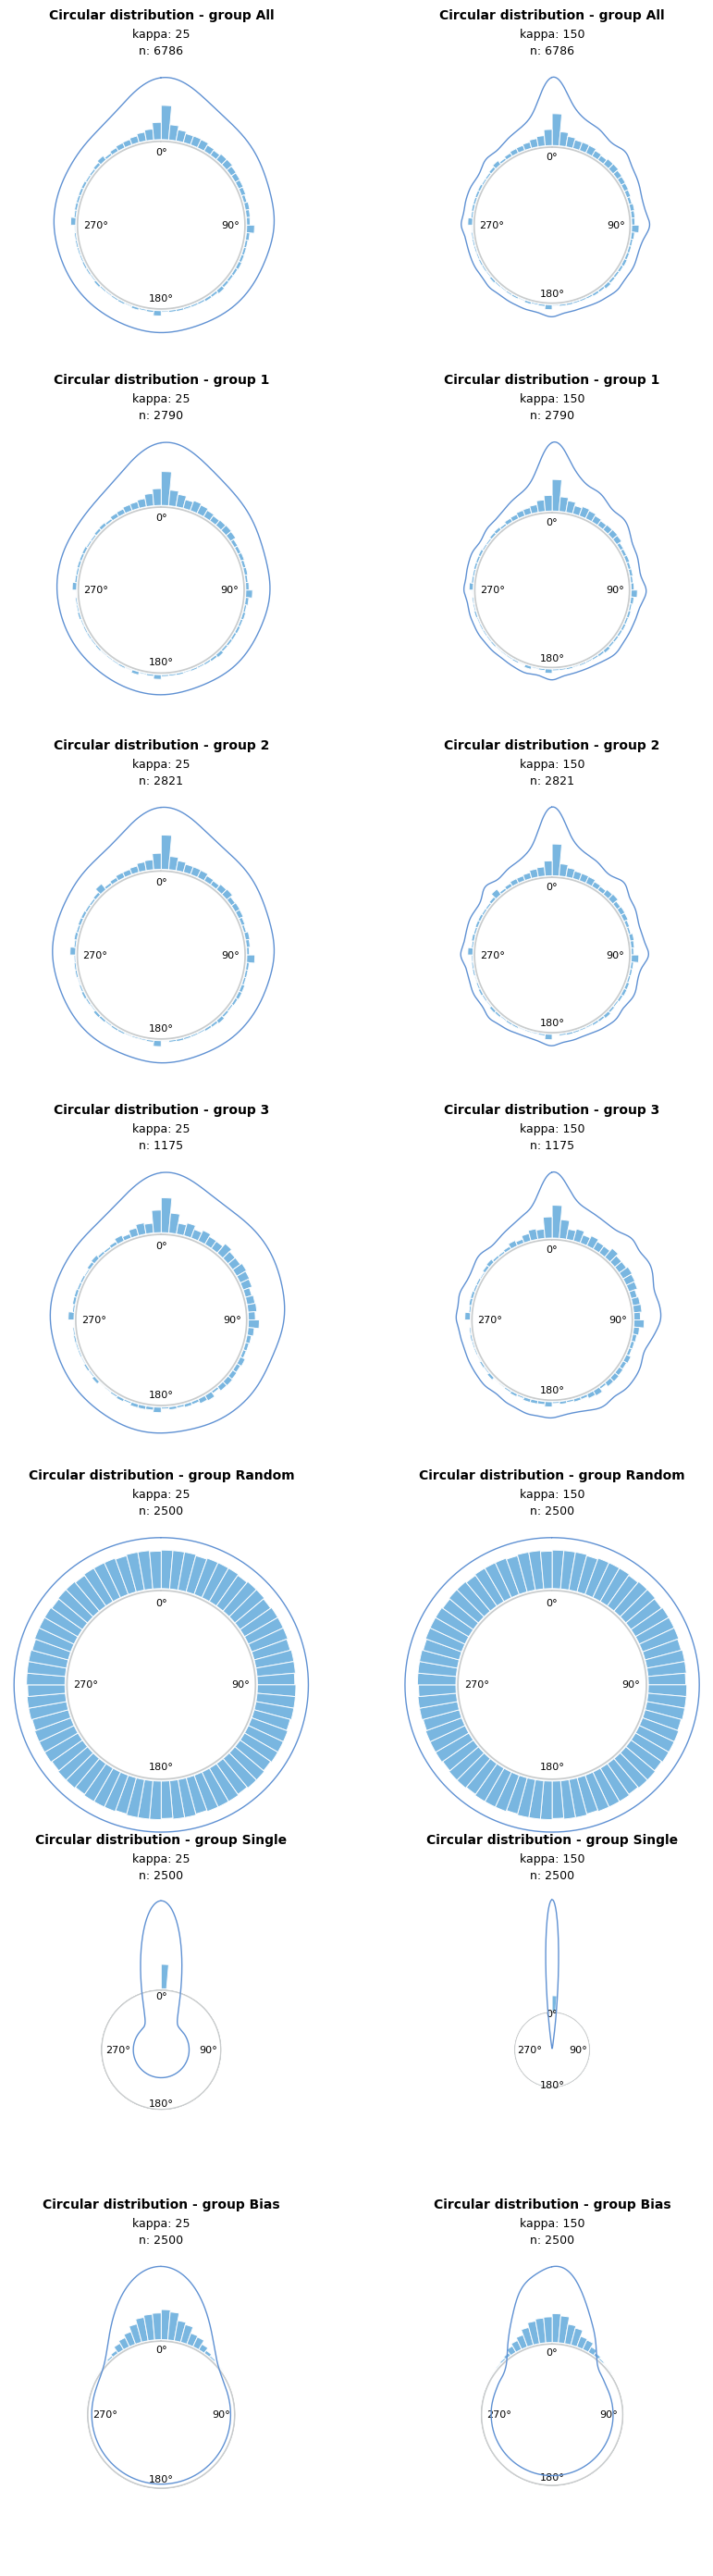

In [10]:
fig, ax = plt.subplots(nrows=len(group_angles), ncols=2,subplot_kw={"projection": "polar"}, figsize=(10, 5 * len(group_angles)), squeeze=False)

for group, angles in group_angles.items():
    if not hasattr(fig, "_axes_grid"):
        fig._axes_grid = np.atleast_2d(ax)
        fig._plot_row = 0

    row_axes = fig._axes_grid[fig._plot_row]
    fig = classic_polar_dist(
        angles,
        bins=72,
        kappa=25,
        title_suffix=f"- group {group}",
        fig=fig,
        ax=row_axes[0]
    )
    ax = row_axes[1]
    fig._plot_row += 1
    fig = classic_polar_dist(angles, bins=72, kappa=150, title_suffix=f"- group {group}", fig=fig, ax=ax)
    

In [ ]:
for group, angles in group_angles.items():
    save_svg(classic_polar_dist(angles, bins=72, kappa=25,  title_suffix=f"- group {group}"), f"Classical polar - group_{group} - kappa_25.svg")
    save_svg(classic_polar_dist(angles, bins=72, kappa=150, title_suffix=f"- group {group}"), f"Classical polar - group_{group} - kappa_150.svg")

# **Statistical tests** (Circular Data)

### **Rayleigh test:**
***testing uniformity*** *<- whether are the data distributed uniformly around a circle*

In [12]:
print("Rayleigh test results:\n")
for group, angles in group_angles.items():
    result = circ.rayleigh_test(angles)
    print(f"Group {group}\n  r: {result.r:.5f}\n  z: {result.z:.5f}\n  pval: {result.pval:.5f}\n")


Rayleigh test results:

Group All
  r: 0.44473
  z: 1342.15096
  pval: 0.00000

Group 1
  r: 0.47648
  z: 633.42799
  pval: 0.00000

Group 2
  r: 0.42514
  z: 509.87580
  pval: 0.00000

Group 3
  r: 0.44014
  z: 227.62356
  pval: 0.00000

Group Random
  r: 0.00000
  z: 0.00000
  pval: 1.00000

Group Single
  r: 1.00000
  z: 2500.00000
  pval: 0.00000

Group Bias
  r: 0.94939
  z: 2253.33798
  pval: 0.00000



### **V-Test:**
***testing bias*** *<- whether are angles biased towards the given (expected) 0° value* 

In [13]:
print("V-test results:\n")
for group, angles in group_angles.items():
    result = circ.V_test(np.deg2rad(0), angles)
    print(f"Group {group}\n  V: {result.V:.5f}\n  u: {result.u:.5f}\n  pval: {result.pval:.5f}\n")

V-test results:

Group All
  V: 2876.35228
  u: 49.37989
  pval: 0.00000

Group 1
  V: 1283.54961
  u: 34.36573
  pval: 0.00000

Group 2
  V: 1167.94147
  u: 31.09815
  pval: 0.00000

Group 3
  V: 424.86120
  u: 17.52843
  pval: 0.00000

Group Random
  V: nan
  u: nan
  pval: nan

Group Single
  V: 2500.00000
  u: 70.71068
  pval: 0.00000

Group Bias
  V: 2373.37754
  u: 67.12925
  pval: 0.00000



### **Watson-Williamns test across replicates:**
***testing reproducibility*** *<- whether are there significant differences between replicates*

In [14]:
result = circ.watson_williams_test([angles for angles in rep_angles.values() if angles.size > 0])
result
print(f"Watson-Williams test:\n  F: {result.F:.5f}\n  pval: {result.pval:.5f}\n  df_between: {result.df_between}\n  df_within: {result.df_within}\n  k: {result.k}\n  N: {result.N}\n")

Watson-Williams test:
  F: 34.81152
  pval: 0.00000
  df_between: 2
  df_within: 6783
  k: 3
  N: 6786



# **Statistical tests** (Linear Data)

### Import libraries

In [15]:
from scipy import stats

### Data Preparation

**Load Data:**

In [16]:
data_lin = pd.read_csv(r"C:\Users\modri\Downloads\Track stats 2026-04-23.csv")
data_lin

,Condition,Replicate,Track ID,Track UID,Track length,Speed min,Speed max,Speed mean,Speed sd,Speed median,...,Forward progression linearity,Direction mean,Direction var,Mean directional change,Mean directional change rate,Track displacement,Straightness ratio,Track points,Replicate color,Condition color
0,DMSO,1,6_0.0,0,114.010562,0.037773,0.155048,0.096619,0.029082,0.097121,...,0.800846,-2.527010,0.198404,19.461872,0.016218,92.852390,0.814419,60,#eae2b7,#000000
1,DMSO,1,6_1.0,1,122.710919,0.022674,0.240041,0.103992,0.057410,0.095117,...,0.250209,2.702753,0.746661,46.148295,0.038457,31.223732,0.254450,60,#eae2b7,#000000
2,DMSO,1,6_10.0,2,60.434857,0.006592,0.125855,0.051216,0.026095,0.051198,...,0.524950,2.371453,0.553058,42.487993,0.035407,32.263009,0.533848,60,#eae2b7,#000000
3,DMSO,1,6_100.0,3,109.771937,0.034469,0.278198,0.093027,0.042969,0.084068,...,0.764341,2.407828,0.228382,20.309142,0.016924,85.325281,0.777296,60,#eae2b7,#000000
4,DMSO,1,6_101.0,4,117.404701,0.025701,0.206076,0.099496,0.038083,0.104158,...,0.775624,-1.874993,0.216768,22.607436,0.018840,92.605306,0.788770,60,#eae2b7,#000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4760,compound C 0.3 μM,4,4_95.0,3995,56.400155,0.007529,0.091687,0.047797,0.022868,0.048734,...,0.219468,1.841330,0.902840,46.959137,0.039133,12.587840,0.223188,60,#b5171a,#85ed7e
4761,compound C 0.3 μM,4,4_96.0,3996,125.963240,0.006004,0.279149,0.106749,0.075973,0.101061,...,0.654417,2.126420,0.462430,35.043024,0.029203,83.829635,0.665509,60,#b5171a,#85ed7e
4762,compound C 0.3 μM,4,4_97.0,3997,241.399765,0.011637,0.414943,0.204576,0.108899,0.218236,...,0.596527,-1.931377,0.609739,23.296700,0.019414,146.442234,0.606638,60,#b5171a,#85ed7e
4763,compound C 0.3 μM,4,4_98.0,3998,232.772769,0.025397,0.376875,0.197265,0.093072,0.208606,...,0.619101,2.437919,0.380240,31.472305,0.026227,146.552361,0.629594,60,#b5171a,#85ed7e


**Prepare data for automated processing:**

In [17]:
categories = {}

for cond in data_lin["Condition"].unique():
    cond_data = data_lin.loc[data_lin["Condition"] == cond]
    replicates = {}
    for rep in cond_data["Replicate"].unique():
        rep_data = cond_data.loc[cond_data["Replicate"] == rep]
        replicates.update({rep: rep_data})
    categories.update({cond: {'cond_data': cond_data, 'rep_data': replicates}})

### **Shapiro Wilk test:**

***testing normality*** *<- whether are the data distributed normally*

* Normality is tested across data in each condition, first without, and in case of failiure, with logarithmic tranformation.

* Q-Q plots and histograms are generated for each condition before or after logarithmic transformation


In [27]:
class info:
    log_transform = False


def _shapiro(col: str, *, dct: dict = categories, verbose: bool = False, plot: bool = False, allow_log_transform: bool = True) -> dict:
    
    if verbose:
        print(f"Shapiro-Wilk normality test for '{col}' data:")
    results = {}
    info.log_transform = False
    
    def _iterate():
        for cond, data in dct.items():
            if verbose:
                print(f"\n{cond}:")

            cond_data = data['cond_data']
            values = cond_data[col].dropna()
            if info.log_transform and allow_log_transform:
                if np.any(values <= 0):
                    if verbose:
                        print(f"  -> Cannot log-transform data for condition '{cond}' because it contains non-positive values.")
                        print('  Data is not normal and cannot be log-transformed. Consider using non-parametric tests.')
                    results[cond] = {'error': 'Non-positive values prevent log transformation'}
                    break
                values = np.log(values)
            stat, pval = stats.shapiro(values)

            if pval < 0.05:
                if verbose:
                    print(f"  -> Failed normality test (p={pval:.5f})")
                if not info.log_transform and allow_log_transform:
                    if verbose:
                        print('    -> Going to log-transform and retest.')
                    info.log_transform = True
                    _iterate()
                else:
                    if verbose:
                        print('  Data is not normal even after log-transform. Consider using non-parametric tests.')
                    results[cond] = {'pvalue': pval, 'n': values.size, 'statistic': stat, 'log_transformed': info.log_transform}
            else:
                if verbose:
                    print(f"  -> Passed normality test (p={pval:.5f})")
                    print('  Data is normal.' + (' (after log-transform)' if info.log_transform else ''))
                results[cond] = {'pvalue': pval, 'n': values.size, 'statistic': stat, 'log_transformed': info.log_transform}
    
    _iterate()

    if plot:
        fig, axes = plt.subplots(len(dct), 2, figsize=(10, 5 * len(dct)), squeeze=False)

        for i, (cond, group_data) in enumerate(dct.items()):
            plot_data = group_data["cond_data"][col].dropna().astype(float).values
            plot_data = plot_data[np.isfinite(plot_data)]

            if info.log_transform:
                plot_data = plot_data[plot_data > 0]
                plot_data = np.log(plot_data)

            plot_data = plot_data[np.isfinite(plot_data)]
            qq_ax, hist_ax = axes[i]

            if plot_data.size < 3:
                qq_ax.text(0.5, 0.5, "Not enough finite data", ha="center", va="center", transform=qq_ax.transAxes)
                hist_ax.text(0.5, 0.5, "Not enough finite data", ha="center", va="center", transform=hist_ax.transAxes)
                qq_ax.set_axis_off()
                hist_ax.set_axis_off()
                continue

            stats.probplot(plot_data, plot=qq_ax)
            qq_ax.set_title(f"{cond} - Q-Q plot")

            hist_ax.hist(plot_data, bins=30, color="#0004ff", edgecolor="white", alpha=0.95)
            hist_ax.set_title(f"{cond} - {'Log-transformed' if info.log_transform else 'Original'}")
            hist_ax.set_xlabel(col)
            hist_ax.set_ylabel("Count")

        plt.tight_layout()
    
    return results


DMSO:
  error: Non-positive values prevent log transformation, 

compound A 10 μM:
  pvalue: 0.00000, n: 1089, statistic: 0.92846, log_transformed: True, 

compound B 10 μM:
  pvalue: 0.00000, n: 664, statistic: 0.91585, log_transformed: True, 

compound B 3 μM:
  pvalue: 0.00000, n: 607, statistic: 0.90946, log_transformed: True, 

compound C 3 μM:
  pvalue: 0.00000, n: 765, statistic: 0.93440, log_transformed: True, 

compound C 0.3 μM:
  pvalue: 0.00000, n: 635, statistic: 0.89859, log_transformed: True, 


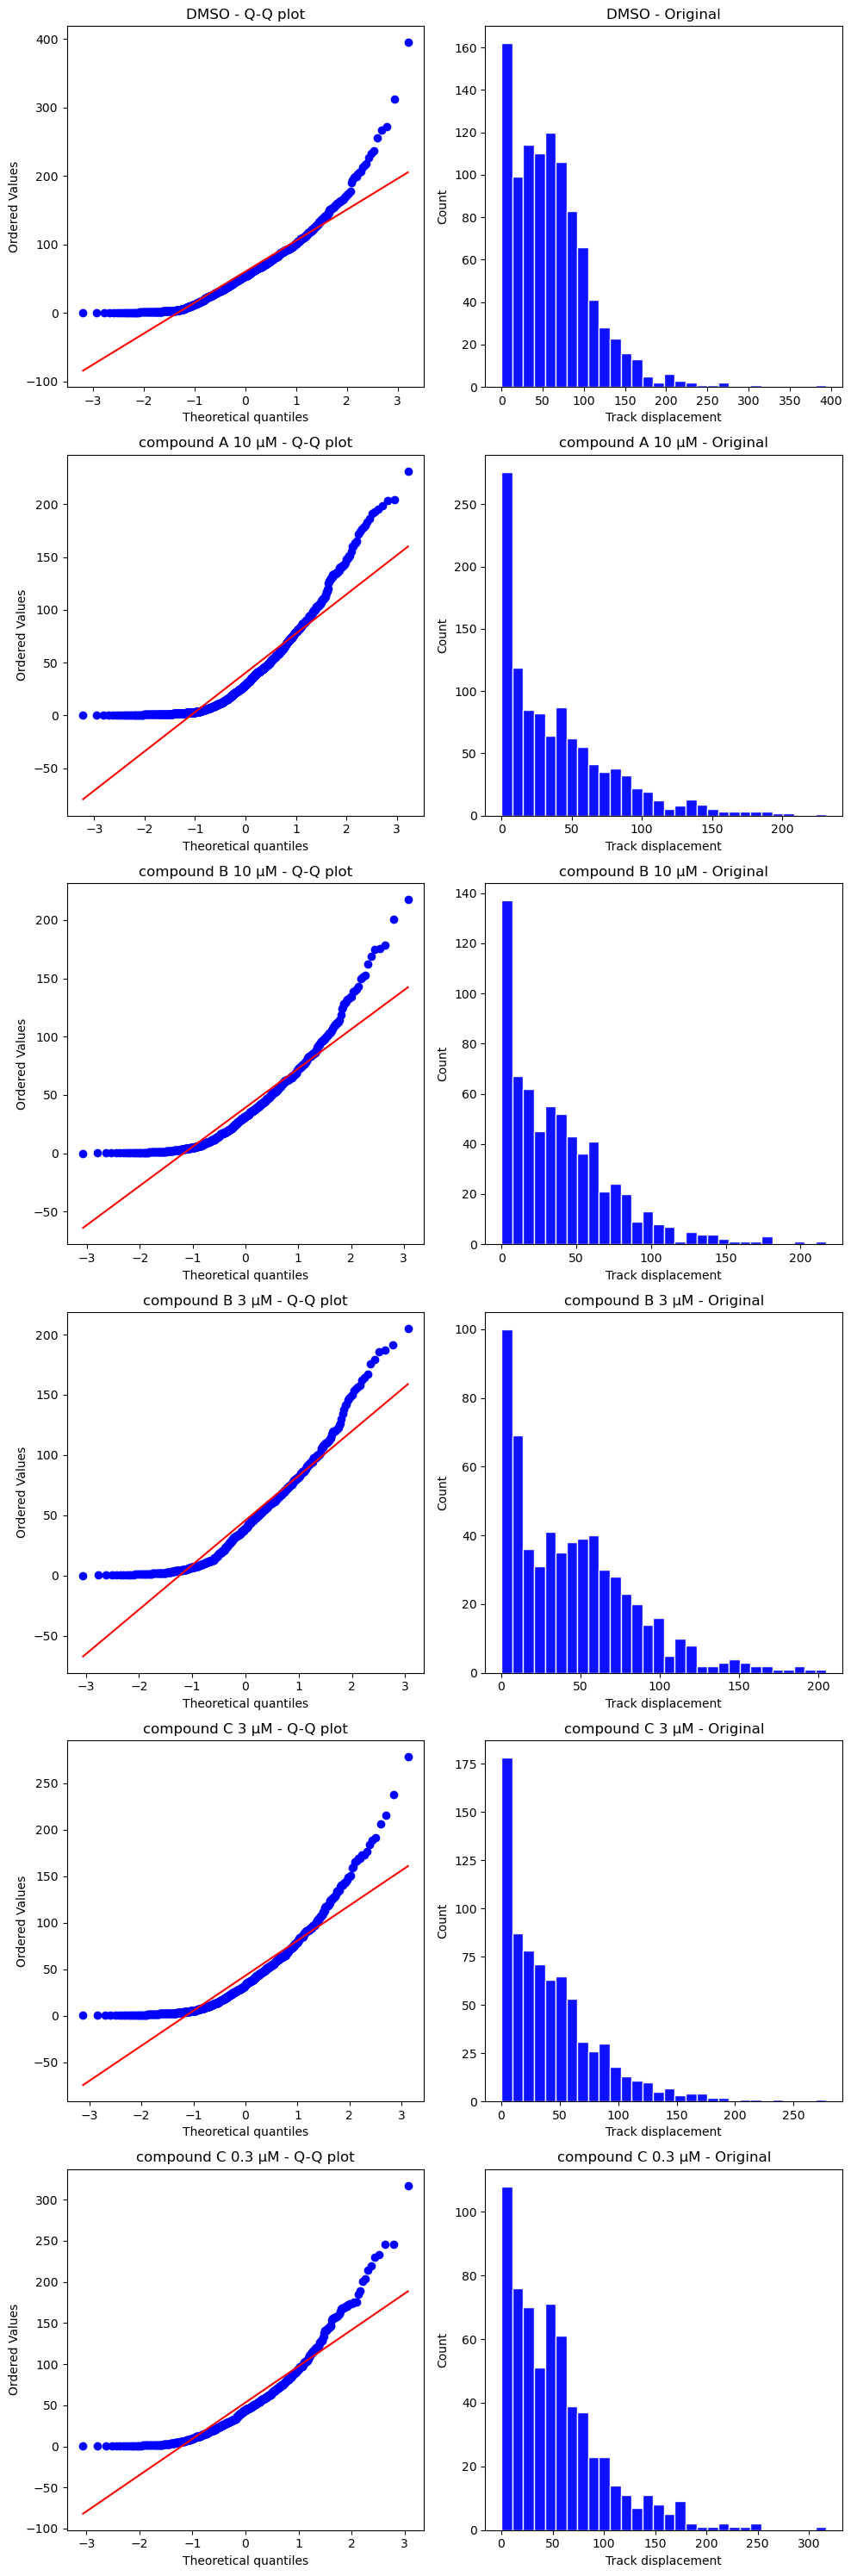

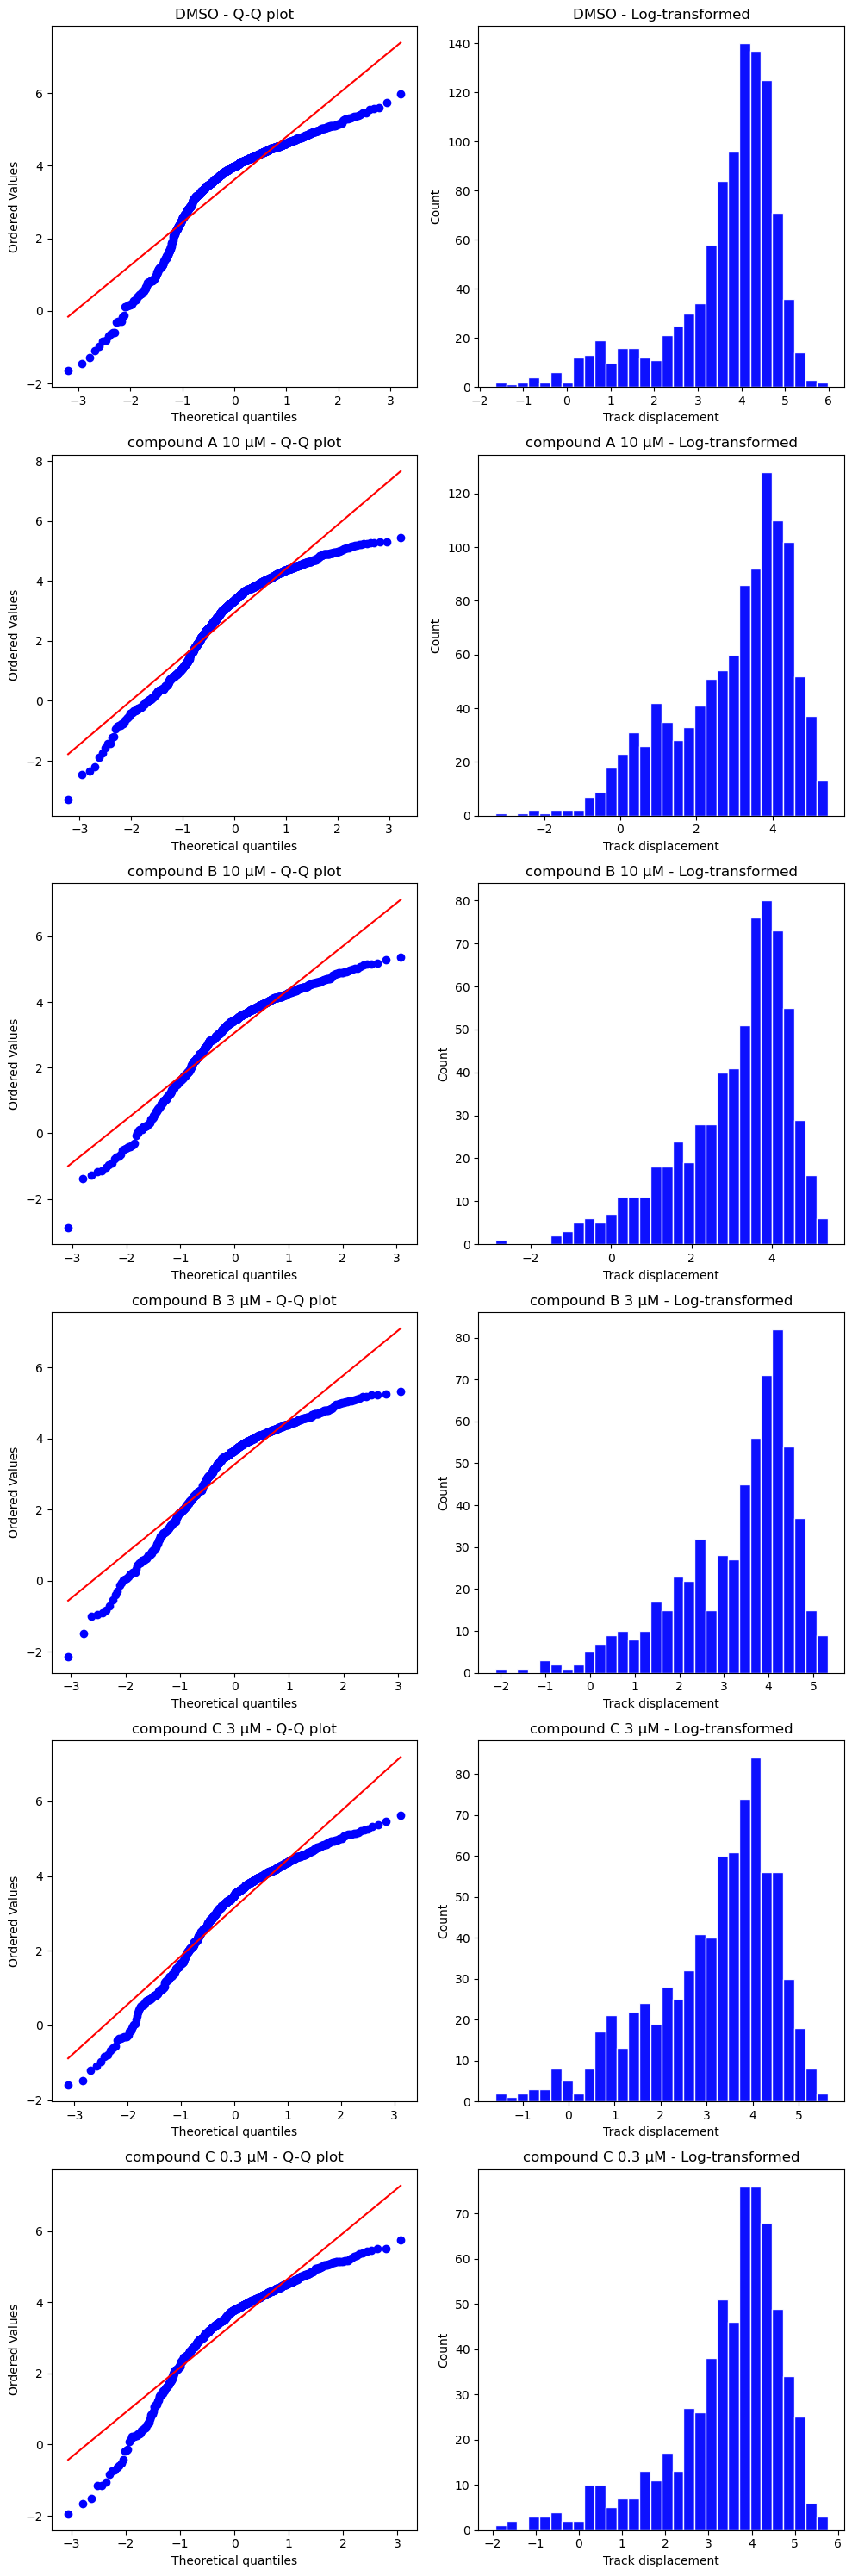

In [28]:
data_col = "Track displacement"

results = _shapiro(data_col, plot=True, allow_log_transform=False)
results = _shapiro(data_col, plot=True)

for cond, res in results.items():
    print(f"\n{cond}:")
    print("  ", end='')
    for key, value in res.items():
        if isinstance(value, float):
            print(f"{key}: {value:.5f}", end=', ')
        else:
            print(f"{key}: {value}", end=', ')
    print('')


### **Kruskal-Wallis test:**

***testing differences** <- testing whether there are significant differences between medians of the data in each conditions (i.o. whether data from all categories belongs to the same 'population')*

In [29]:
data_col = "Track displacement"

# List of condition data arrays for Kruskal-Wallis test
_cond_data_list = [data['cond_data'][data['cond_data']['Condition'] == cond][data_col].dropna().values for cond, data in categories.items()]

result = stats.kruskal(*_cond_data_list)
print(f"Kruskal-Wallis test results:\n  pvalue: {result.pvalue:.5f}\n  statistic: {result.statistic:.5f}\n")

Kruskal-Wallis test results:
  pvalue: 0.00000
  statistic: 180.34191



### **Mann-Whitney test** -> comparing control to each inhibitor individually:

In [30]:
compare_to = 'DMSO'

data_col = "Straightness ratio"

for cond, data in categories.items():
    if cond == compare_to:
        continue
    cond_data = data['cond_data']
    values_control = categories[compare_to]['cond_data'][categories[compare_to]['cond_data']['Condition'] == compare_to][data_col].dropna().values
    values_cond = cond_data[cond_data['Condition'] == cond][data_col].dropna().values
    stat, pval = stats.mannwhitneyu(values_control, values_cond, alternative='two-sided')
    print(f"Comparison {compare_to} vs {cond}:\n  Mann-Whitney U: {stat:.5f}\n  p-value: {pval:.5f}\n")

Comparison DMSO vs compound A 10 μM:
  Mann-Whitney U: 623017.00000
  p-value: 0.00000

Comparison DMSO vs compound B 10 μM:
  Mann-Whitney U: 361312.00000
  p-value: 0.00411

Comparison DMSO vs compound B 3 μM:
  Mann-Whitney U: 305205.00000
  p-value: 0.98352

Comparison DMSO vs compound C 3 μM:
  Mann-Whitney U: 400041.00000
  p-value: 0.14234

Comparison DMSO vs compound C 0.3 μM:
  Mann-Whitney U: 319669.00000
  p-value: 0.95041

